In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
import os
from dotenv import load_dotenv

load_dotenv()

from langchain_groq import ChatGroq

model = ChatGroq(
    model_name="llama-3.1-8b-instant",
    temperature=0
)

In [ ]:
class BlogState(TypedDict):
    title: str
    outline:str
    content: str

In [ ]:
def create_outline(state: BlogState) -> BlogState:
    # fetch title
     title = state['title']
    # call llm gen outline
     prompt= f'Generate a detailed outline for a blog on the topic - {title}'
     outline = model.invoke(prompt).content
     #update state
     state['outline']= outline
     return state

In [6]:
def create_blog(state: BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']
    prompt = f'Write a detailed blog on the title - {title} using the following outline\n {outline}'
    content = model.invoke(prompt).content
    state['content'] = content
    return state

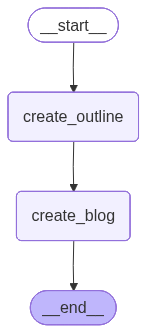

In [7]:
graph = StateGraph(BlogState)

#nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

#edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog', END)
graph.compile()

In [ ]:
workflow = graph.compile()

In [9]:
intial_state= {'title': 'Rise of AI in India'}
final_state = workflow.invoke(intial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': "**Title:** The Rise of AI in India: Opportunities, Challenges, and Future Prospects\n\n**I. Introduction**\n\n* Brief overview of AI and its growing importance globally\n* Importance of India in the AI landscape\n* Thesis statement: India is poised to become a major player in the AI industry, driven by government initiatives, technological advancements, and a growing talent pool.\n\n**II. Government Initiatives and Policies**\n\n* Overview of government initiatives to promote AI in India (e.g., Digital India, Make in India, Start-up India)\n* Key policies and regulations supporting AI development (e.g., National Policy on Artificial Intelligence, 2018)\n* Examples of government-funded AI research and development projects\n\n**III. Technological Advancements**\n\n* Overview of AI technologies being developed in India (e.g., machine learning, natural language processing, computer vision)\n* Examples of Indian startups and companies working on 

In [10]:
print(final_state['outline'])

**Title:** The Rise of AI in India: Opportunities, Challenges, and Future Prospects

**I. Introduction**

* Brief overview of AI and its growing importance globally
* Importance of India in the AI landscape
* Thesis statement: India is poised to become a major player in the AI industry, driven by government initiatives, technological advancements, and a growing talent pool.

**II. Government Initiatives and Policies**

* Overview of government initiatives to promote AI in India (e.g., Digital India, Make in India, Start-up India)
* Key policies and regulations supporting AI development (e.g., National Policy on Artificial Intelligence, 2018)
* Examples of government-funded AI research and development projects

**III. Technological Advancements**

* Overview of AI technologies being developed in India (e.g., machine learning, natural language processing, computer vision)
* Examples of Indian startups and companies working on AI innovations (e.g., AI-powered healthcare, education, financ

In [11]:
print(final_state['content'])

**The Rise of AI in India: Opportunities, Challenges, and Future Prospects**

**I. Introduction**

Artificial Intelligence (AI) has become a transformative force globally, revolutionizing industries and transforming the way we live and work. As the world becomes increasingly dependent on AI, India is poised to become a major player in the AI industry. With a growing talent pool, government initiatives, and technological advancements, India is well-positioned to capitalize on the AI boom. In this blog post, we will explore the rise of AI in India, its opportunities, challenges, and future prospects.

**II. Government Initiatives and Policies**

The Indian government has launched several initiatives to promote AI development and adoption in the country. Some notable initiatives include:

* **Digital India**: Launched in 2015, Digital India aims to transform India into a digitally empowered society and knowledge economy. AI is a key component of this initiative, with a focus on developing